<div style="
    background: #0f3460;
    padding: 14px 48px;
    border-left: 5px solid #e94560;
    font-family: 'Segoe UI', sans-serif;
    width: 100vw;
    box-sizing: border-box;
    position: relative;
    left: 50%;
    transform: translateX(-50%);
    overflow: hidden;
">
    <p style="color: rgba(255,255,255,0.5); font-size: 0.75em; margin: 0 0 4px 0;
       letter-spacing: 2px; text-transform: uppercase;">
        Nhập môn học máy &nbsp;|&nbsp; Báo cáo Đồ án 3 &nbsp;|&nbsp; CQ2023/24
    </p>
    <div style="display: flex; align-items: baseline; gap: 20px; flex-wrap: wrap;">
        <div>
            <h1 style="color: #ffffff; font-size: 1.4em; margin: 0 0 2px 0; font-weight: 700;">
                Notebook: PointNet 3D Classification
            </h1>
            <p style="color: #89b4fa; font-size: 0.88em; margin: 0;">
                3D Point Cloud · Classification &amp; Segmentation · Permutation Invariance · Spatial Transformer (T-Net)
            </p>
        </div>
        <span style="color: rgba(255,255,255,0.5); font-size: 0.8em; margin-left: auto; white-space: nowrap;">
            5 classes &nbsp;·&nbsp; 2 models &nbsp;·&nbsp; ModelNet dataset
        </span>
    </div>
</div>


## Table of Contents

- [1. Bài toán và đặc điểm của point cloud](#1-bài-toán-và-đặc-điểm-của-point-cloud)
- [2. Nền tảng toán học](#2-nền-tảng-toán-học)
  - [2.1 Symmetric function và permutation invariance](#21-symmetric-function-và-permutation-invariance)
  - [2.2 Critical point set](#22-critical-point-set)
  - [2.3 Tại sao cần T-Net?](#23-tại-sao-cần-t-net)
- [3. Chuẩn bị dữ liệu](#3-chuẩn-bị-dữ-liệu)
  - [3.1 Dataset và cách tổ chức](#31-dataset-và-cách-tổ-chức)
  - [3.2 Normalize về unit sphere](#32-normalize-về-unit-sphere)
  - [3.3 Augmentation khi huấn luyện](#33-augmentation-khi-huấn-luyện)
- [4. PointNet Basic, không có T-Net](#4-pointnet-basic-không-có-t-net)
  - [4.1 Tại sao dùng Conv1d thay vì Linear?](#41-tại-sao-dùng-conv1d-thay-vì-linear)
  - [4.2 Kiến trúc PointNet Basic](#42-kiến-trúc-pointnet-basic)
- [5. T-Net và cơ chế spatial transform](#5-t-net-và-cơ-chế-spatial-transform)
  - [5.1 Ý tưởng](#51-ý-tưởng)
  - [5.2 Kiến trúc InputTransformNet](#52-kiến-trúc-inputtransformnet)
  - [5.3 Orthogonal regularization](#53-orthogonal-regularization)
- [6. PointNet Full, pipeline hoàn chỉnh](#6-pointnet-full-pipeline-hoàn-chỉnh)
- [7. Huấn luyện](#7-huấn-luyện)
  - [7.1 Cấu hình](#71-cấu-hình)
  - [7.2 Lưu model](#72-lưu-model)
- [8. Đánh giá và so sánh](#8-đánh-giá-và-so-sánh)
  - [8.1 Load model đã train](#81-load-model-đã-train)
  - [8.2 Confusion matrix](#82-confusion-matrix)
  - [8.3 So sánh Basic và Full](#83-so-sánh-basic-và-full)
- [9. Robustness và critical point set](#9-robustness-và-critical-point-set)
  - [9.1 Permutation invariance test](#91-permutation-invariance-test)
  - [9.2 Robustness với điểm bị mất](#92-robustness-với-điểm-bị-mất)
  - [9.3 Robustness với nhiễu Gaussian](#93-robustness-với-nhiễu-gaussian)
  - [9.4 Visualize critical point set](#94-visualize-critical-point-set)
- [10. Kết luận](#10-kết-luận)


Paper gốc: Qi et al., "PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation", CVPR 2017.

Notebook này đi theo đúng thứ tự của paper: từ bài toán, nền tảng toán học, cài đặt kiến trúc, huấn luyện, đến thực nghiệm kiểm chứng các tính chất lý thuyết. Web demo tương tác nằm ở ../frontend và ../backend.


In [2]:
import os
import sys
import math
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Paths
cwd = Path(os.getcwd())
BACKEND_DIR = None
for p in [cwd, cwd / '..', cwd / '../..', cwd / '../../..']:
    resolved = p.resolve()
    if (resolved / 'backend' / 'main.py').exists():
        BACKEND_DIR = (resolved / 'backend').resolve()
        break

if BACKEND_DIR is None:
    BACKEND_DIR = (cwd / '../backend').resolve()

NOTEBOOK_DIR = (BACKEND_DIR / '../ai_core/notebooks').resolve()
SAMPLE_DIR   = (BACKEND_DIR / '../storage/data/sample_clouds').resolve()
MODELS_DIR   = (BACKEND_DIR / '../storage/weights').resolve()
FIG_DIR      = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Thêm backend vào sys.path để import model
sys.path.insert(0, str(BACKEND_DIR))

# Import từ file utils và backend model
from pointnet_utils import (
    normalize, augment, preprocess,
    plot_cloud, PointCloudDataset,
    DEFAULT_NUM_POINTS
)
from core.pointnet_model import (
    PointNetBasic, PointNetFull,
    InputTransformNet, FeatureTransformNet,
    feature_transform_regularizer
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_POINTS = DEFAULT_NUM_POINTS
CLASSES    = ['airplane', 'chair', 'car', 'lamp', 'table']

print(f"PyTorch {torch.__version__}")
print(f"Device : {device}")
print(f"Sample dir: {SAMPLE_DIR.exists()}")

PyTorch 2.12.0+cpu
Device : cpu
Sample dir: True


## **1. Bài toán và đặc điểm của point cloud**

Khi xử lý ảnh 2D, mỗi pixel có một vị trí cố định trên lưới đều. Thứ tự đầu vào luôn nhất quán, nên CNN có thể dùng convolution trượt trên lưới đó mà không lo thứ tự thay đổi. Với dữ liệu 3D thì khác.

Có ba cách phổ biến để biểu diễn vật thể 3D:

- *Voxel grid*: chia không gian thành các ô lập phương nhỏ, đánh dấu ô nào có vật thể. Trực quan nhưng tốn bộ nhớ theo lũy thừa 3 của độ phân giải. Tăng độ phân giải lên gấp đôi thì bộ nhớ tăng gấp 8.

- *Multi-view projection*: chiếu vật thể ra nhiều ảnh 2D từ nhiều góc rồi xử lý từng ảnh bằng CNN. Mất thông tin chiều sâu và phải chọn trước các góc nhìn.

- *Point cloud*: lưu trực tiếp tọa độ $(x, y, z)$ của từng điểm trên bề mặt vật thể. Đây là output tự nhiên của cảm biến LiDAR và camera depth, không cần bước chuyển đổi nào thêm.

Point cloud có ba đặc điểm khiến nó không thể đưa thẳng vào mạng nơ-ron thông thường:

1. *Unordered*: nếu ta có 1024 điểm mô tả một chiếc ghế, hoán đổi thứ tự của 1024 điểm đó không làm thay đổi hình dạng ghế, nhưng tạo ra vector đầu vào khác hẳn. Mạng thông thường sẽ cho kết quả khác nhau dù đang nhìn cùng một 
vật thể.

2. *Không có láng giềng rõ ràng*: các điểm không nằm trên lưới nên không áp được convolution trực tiếp như với ảnh.

3. *Số lượng điểm biến đổi*: tùy cảm biến và cách sampling, cùng một vật thể có thể cho ra 512 hoặc 2048 điểm.

PointNet giải quyết ba vấn đề này bằng kiến trúc cho phép output không phụ thuộc vào thứ tự input, tính chất gọi là permutation invariance.

In [3]:
for cls in CLASSES:
    pts = np.load(SAMPLE_DIR / f'{cls}_sample.npy')
    print(f"{cls:10s}  shape={pts.shape}  "
          f"x=[{pts[:,0].min():.2f}, {pts[:,0].max():.2f}]  "
          f"y=[{pts[:,1].min():.2f}, {pts[:,1].max():.2f}]  "
          f"z=[{pts[:,2].min():.2f}, {pts[:,2].max():.2f}]")

airplane    shape=(2048, 3)  x=[-1.00, 0.65]  y=[-0.58, 0.58]  z=[-0.10, 0.16]
chair       shape=(2048, 3)  x=[-0.45, 0.43]  y=[-0.35, 0.52]  z=[-0.65, 0.91]
car         shape=(2048, 3)  x=[-0.87, 0.87]  y=[-0.40, 0.39]  z=[-0.38, 0.41]
lamp        shape=(2048, 3)  x=[-0.28, 0.28]  y=[-0.28, 0.28]  z=[-1.00, 0.53]
table       shape=(2048, 3)  x=[-0.79, 0.79]  y=[-0.50, 0.49]  z=[-0.59, 0.25]


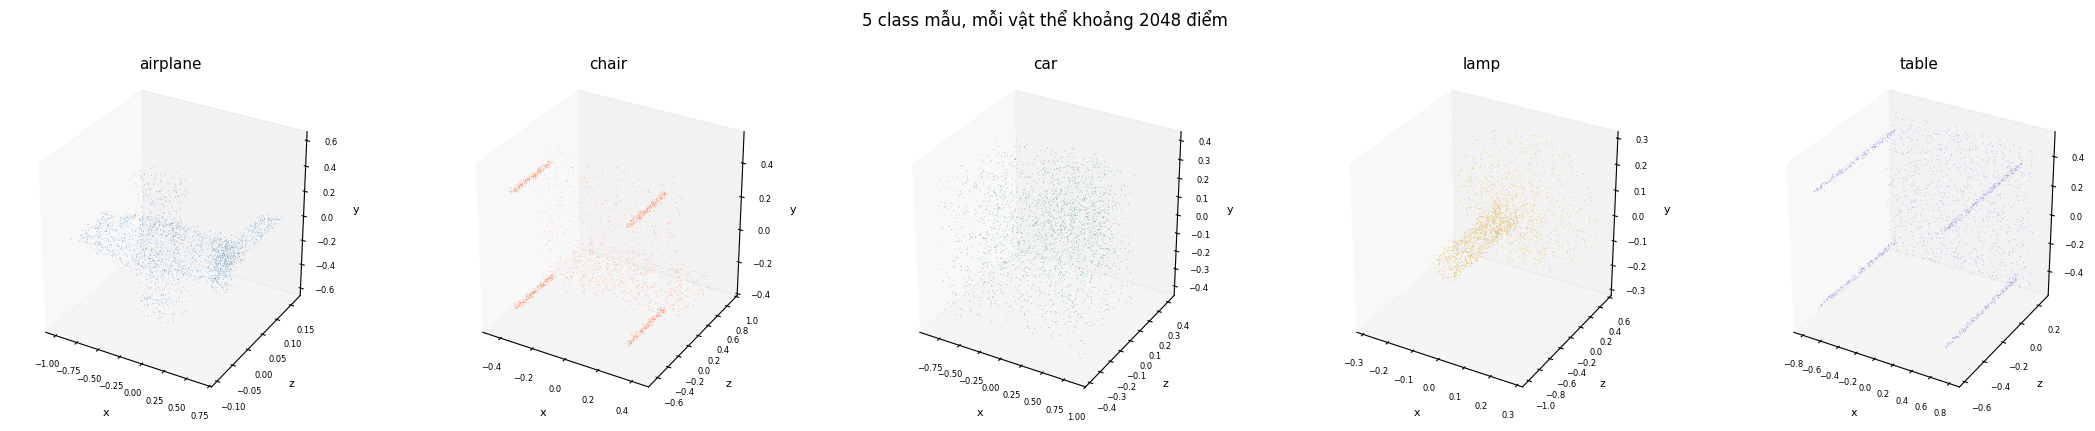

In [4]:
COLORS = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']

fig = plt.figure(figsize=(22, 4))
for i, (cls, col) in enumerate(zip(CLASSES, COLORS)):
    pts = np.load(SAMPLE_DIR / f'{cls}_sample.npy')
    ax  = fig.add_subplot(1, 5, i + 1, projection='3d')
    plot_cloud(pts, ax, title=cls, color=col)

plt.suptitle('5 class mẫu, mỗi vật thể khoảng 2048 điểm', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'point_clouds_5class.png', dpi=150, bbox_inches='tight')
plt.show()

## **2. Nền tảng toán học**

### **2.1 Symmetric function và permutation invariance**

Cho một tập $S = \{x_1, x_2, \ldots, x_n\}$ với $x_i \in \mathbb{R}^3$. Ta cần thiết kế hàm $f$ sao cho với mọi hoán vị $\sigma$:

$$f\!\left(\{x_1, \ldots, x_n\}\right) = f\!\left(\{x_{\sigma(1)}, \ldots, x_{\sigma(n)}\}\right)$$

Paper chứng minh rằng với điều kiện $h$ và $g$ đủ năng lực biểu diễn, bất kỳ hàm liên tục nào thỏa điều kiện trên đều có thể xấp xỉ bởi:

$$f\!\left(\{x_1, \ldots, x_n\}\right) \;\approx\; g\!\left(\,\max_{i=1}^{n} h(x_i)\right)$$

Trong đó:
- $h$ là shared MLP, xử lý từng điểm độc lập, điểm $i$ không biết gì về các điểm khác.
- $\max$ là global max pooling theo từng chiều của vector đặc trưng.
- $g$ nhận vector tổng hợp và đưa ra kết quả phân loại cuối.

Lý do global max pooling đảm bảo permutation invariance: max là hàm đối xứng. `max(a, b, c) = max(c, a, b) = max(b, c, a)`. Dù thứ tự đầu vào thay đổi thế nào, giá trị lớn nhất trên từng chiều vẫn không đổi. Cell code bên dưới minh họa trực tiếp điều này.

### **2.2 Critical point set**

Sau khi qua shared MLP, mỗi điểm $x_i$ được ánh xạ thành vector đặc trưng $h(x_i) \in \mathbb{R}^{1024}$. Global max pooling chọn giá trị lớn nhất trên từng chiều trong 1024 chiều. Ở mỗi chiều $j$, chỉ đúng một điểm "cung cấp" giá trị, điểm nào có $h(x_i)[j]$ lớn nhất sẽ thắng. Tập hợp các điểm thắng ít nhất một chiều gọi là critical point set.

Theorem 2 trong paper phát biểu: xóa tất cả điểm không thuộc critical point set không làm thay đổi output của mạng. Nói cách khác, mạng chỉ thực sự dựa vào một số ít điểm khi đưa ra quyết định, phần lớn còn lại không ảnh hưởng gì.

Trong thực nghiệm, các điểm này thường nằm trên góc, cạnh, và các phần đặc trưng nhất của vật thể. Đây là lý do PointNet khá ổn định với việc mất điểm ngẫu nhiên: miễn là critical point set chưa bị mất, kết quả không thay đổi. Section 9 sẽ kiểm chứng điều này bằng thực nghiệm.

### **2.3 Tại sao cần T-Net?**

Công thức $g(\max_i h(x_i))$ đảm bảo permutation invariance nhưng chưa xử lý rotation. Nếu xoay cùng một chiếc ghế 90° quanh trục Y, shared MLP nhận input khác nên feature vector khác, dù đó vẫn là cùng một vật thể.

Giải pháp của PointNet là thêm một mạng nhỏ dự đoán ma trận biến đổi affine để căn chỉnh point cloud về một không gian chuẩn trước khi xử lý. Mạng nhỏ này gọi là T-Net. Chi tiết kiến trúc ở Section 5.

In [5]:
np.random.seed(42)

features = np.random.randn(8, 6).astype(np.float32)
print("Feature matrix gốc (8 điểm x 6 features):")
print(np.round(features, 3))

result_original = features.max(axis=0)
print(f"\nGlobal feature sau max pooling:\n{np.round(result_original, 3)}")

perm = np.random.permutation(8)
result_shuffled = features[perm].max(axis=0)

print(f"\nHoán vị áp dụng: {perm}")
print(f"Global feature sau khi shuffle:\n{np.round(result_shuffled, 3)}")
print(f"\nHai kết quả giống nhau: {np.allclose(result_original, result_shuffled)}")

Feature matrix gốc (8 điểm x 6 features):
[[ 0.497 -0.138  0.648  1.523 -0.234 -0.234]
 [ 1.579  0.767 -0.469  0.543 -0.463 -0.466]
 [ 0.242 -1.913 -1.725 -0.562 -1.013  0.314]
 [-0.908 -1.412  1.466 -0.226  0.068 -1.425]
 [-0.544  0.111 -1.151  0.376 -0.601 -0.292]
 [-0.602  1.852 -0.013 -1.058  0.823 -1.221]
 [ 0.209 -1.96  -1.328  0.197  0.738  0.171]
 [-0.116 -0.301 -1.479 -0.72  -0.461  1.057]]

Global feature sau max pooling:
[1.579 1.852 1.466 1.523 0.823 1.057]

Hoán vị áp dụng: [1 2 5 0 4 6 7 3]
Global feature sau khi shuffle:
[1.579 1.852 1.466 1.523 0.823 1.057]

Hai kết quả giống nhau: True


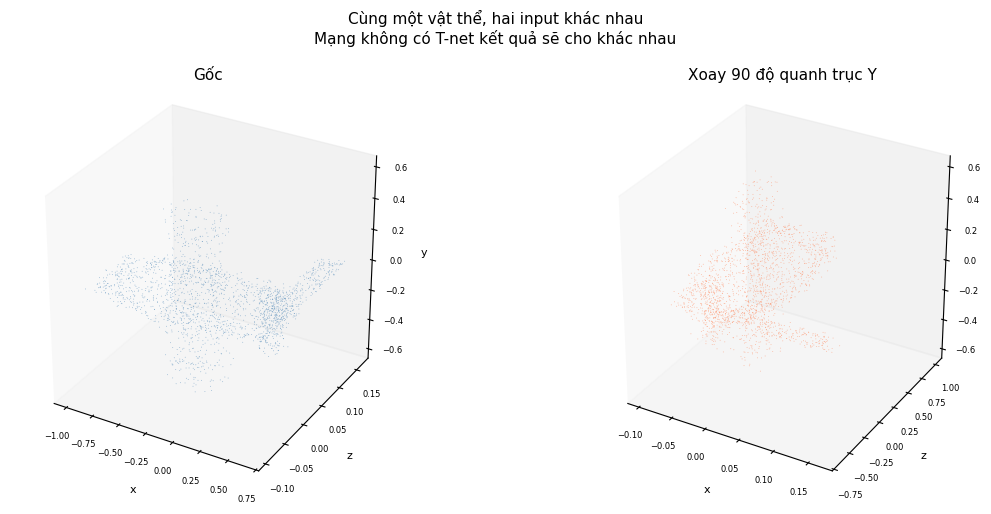

In [6]:
pts = np.load(SAMPLE_DIR / 'airplane_sample.npy').astype(np.float32)
pts = normalize(pts)

theta = np.pi / 2
Ry = np.array([
    [ np.cos(theta), 0, np.sin(theta)],
    [0,              1, 0             ],
    [-np.sin(theta), 0, np.cos(theta)]
], dtype=np.float32)
pts_rotated = pts @ Ry.T

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
plot_cloud(pts,         axes[0], title='Gốc', color='steelblue')
plot_cloud(pts_rotated, axes[1], title='Xoay 90 độ quanh trục Y', color='coral')

plt.suptitle(
    'Cùng một vật thể, hai input khác nhau\n'
    'Mạng không có T-net kết quả sẽ cho khác nhau',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rotation_problem.png', dpi=150, bbox_inches='tight')
plt.show()

## **3. Chuẩn bị dữ liệu**

### **3.1 Dataset và cách tổ chức**

Notebook này dùng 5 class từ ModelNet40: airplane, chair, car, lamp, table. Mỗi 
class có một file .npy lưu khoảng 2048 điểm gốc từ mesh surface, đặt tại 
../backend/data/sample_clouds/.

Vì mỗi class chỉ có một mẫu gốc, ta dùng augmentation để sinh ra nhiều biến thể 
khác nhau trong quá trình huấn luyện. Cách này đơn giản nhưng đủ cho bài toán 
5 class demo. Nếu cần scale lên ModelNet40 đầy đủ thì thay Dataset bằng cách 
load từ thư mục .off hoặc .h5.

### **3.2 Normalize về unit sphere**

Trước khi đưa vào mạng, point cloud cần được normalize về unit sphere:

1. Trừ centroid: dịch chuyển vật thể về gốc tọa độ.
2. Chia cho max distance: scale về hình cầu đơn vị bán kính 1.

$$x_i \leftarrow \frac{x_i - \bar{x}}{\max_j \|x_j - \bar{x}\|_2}$$

Bước này cần thiết vì các vật thể khác nhau có kích thước và vị trí khác nhau 
trong không gian gốc. Normalize đảm bảo tất cả đầu vào nằm trong cùng một phạm 
vi số, giúp quá trình huấn luyện ổn định hơn.

### **3.3 Augmentation khi huấn luyện**

Vì chỉ có một mẫu gốc mỗi class, mỗi lần lấy một sample ta áp augmentation ngẫu 
nhiên gồm:

- Xoay ngẫu nhiên theo cả 3 trục (SO(3) full rotation).
- Scale ngẫu nhiên trong khoảng [0.85, 1.15].
- Thêm nhiễu Gaussian nhỏ, độ lệch chuẩn 0.02.
- Sample ngẫu nhiên n điểm từ tập gốc.

Sau augmentation, normalize lại về unit sphere. Bước xoay theo SO(3) là quan 
trọng nhất, nó buộc mạng phải học các đặc trưng không phụ thuộc hướng thay vì 
chỉ học theo hướng mặc định của mẫu gốc.

In [7]:
train_set = PointCloudDataset(SAMPLE_DIR, CLASSES,
                               samples_per_class=200,
                               num_points=NUM_POINTS,
                               training=True)

val_set   = PointCloudDataset(SAMPLE_DIR, CLASSES,
                               samples_per_class=50,
                               num_points=NUM_POINTS,
                               training=False)

train_loader = DataLoader(train_set, batch_size=16,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=16,
                          shuffle=False, num_workers=0)

pts_batch, labels_batch = next(iter(train_loader))
print(f"Shape batch điểm   : {pts_batch.shape}")
print(f"Labels             : {labels_batch.tolist()}")
print(f"Min/max tọa độ     : {pts_batch.min():.3f} / {pts_batch.max():.3f}")
print(f"Max distance       : {pts_batch.norm(dim=2).max():.4f}  (phải <= 1.0)")

[train] 1000 samples (200 per class, 5 classes)
[val] 250 samples (50 per class, 5 classes)
Shape batch điểm   : torch.Size([16, 1024, 3])
Labels             : [4, 0, 0, 1, 0, 1, 1, 2, 4, 0, 1, 2, 2, 2, 4, 0]
Min/max tọa độ     : -1.000 / 0.963
Max distance       : 1.0000  (phải <= 1.0)


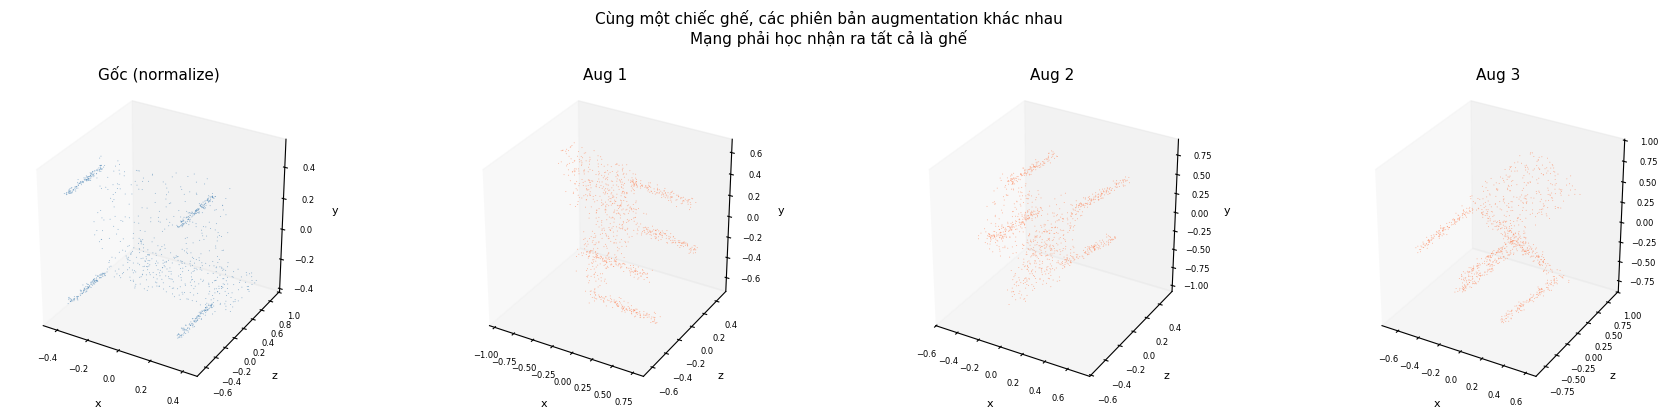

In [8]:
raw = np.load(SAMPLE_DIR / 'chair_sample.npy').astype(np.float32)

fig = plt.figure(figsize=(18, 4))
titles = ['Gốc (normalize)', 'Aug 1', 'Aug 2', 'Aug 3']
colors = ['steelblue', 'coral', 'coral', 'coral']

for i, (title, col) in enumerate(zip(titles, colors)):
    ax  = fig.add_subplot(1, 4, i + 1, projection='3d')
    pts = preprocess(raw, NUM_POINTS) if i == 0 else augment(raw, NUM_POINTS)
    plot_cloud(pts, ax, title=title, color=col, s=0.5)

plt.suptitle(
    'Cùng một chiếc ghế, các phiên bản augmentation khác nhau\n'
    'Mạng phải học nhận ra tất cả là ghế',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## **4. PointNet Basic, không có T-Net**

### **4.1 Tại sao dùng Conv1d thay vì Linear?**

Bước đầu tiên là xử lý từng điểm độc lập qua shared MLP. "Shared" có nghĩa là tất cả các điểm dùng chung một bộ trọng số, giống như convolution trượt qua từng vị trí. Đây chính xác là những gì Conv1d làm khi kernel size = 1.

Nếu dùng nn.Linear, PyTorch kỳ vọng input dạng (B, N, C_in) và áp cùng ma trận trọng số cho từng vị trí N. Về mặt toán học thì tương đương, nhưng Conv1d với kernel size 1 nhanh hơn và được tối ưu tốt hơn trong PyTorch, đặc biệt khi N lớn. Conv1d kỳ vọng input dạng (B, C_in, N), nên ta phải transpose trước khi đưa vào.

Sau khi qua hết shared MLP, mỗi trong số N điểm đã được ánh xạ thành một vector 1024 chiều. Bước tiếp theo là global max pooling để gom tất cả N vector đó lại thành một vector duy nhất (B, 1024) đại diện cho toàn bộ vật thể. Từ đây, một vài lớp fully-connected sẽ đưa ra xác suất phân loại.

### **4.2 Kiến trúc PointNet Basic**

    Input (B, N, 3)
        -> transpose
        -> (B, 3, N)
        -> Conv1d(3, 64, 1)     + BN + ReLU  -> (B, 64, N)
        -> Conv1d(64, 64, 1)    + BN + ReLU  -> (B, 64, N)
        -> Conv1d(64, 64, 1)    + BN + ReLU  -> (B, 64, N)
        -> Conv1d(64, 128, 1)   + BN + ReLU  -> (B, 128, N)
        -> Conv1d(128, 1024, 1) + BN + ReLU  -> (B, 1024, N)
        -> global max pooling                -> (B, 1024)
        -> FC(512) + BN + ReLU + Dropout(0.3)
        -> FC(256) + BN + ReLU + Dropout(0.3)
        -> FC(num_classes)
        -> logits (B, num_classes)

Forward pass trả về hai giá trị: logits và critical_indices. critical_indices là chỉ số của điểm thắng ở từng chiều trong 1024 chiều, dùng để visualize critical point set ở Section 9.


In [9]:
model_basic = PointNetBasic(num_classes=len(CLASSES)).to(device)

dummy = torch.randn(4, NUM_POINTS, 3).to(device)
logits, crit_idx = model_basic(dummy)

print(f"Shape đầu vào          : {dummy.shape}")
print(f"Shape logits đầu ra    : {logits.shape}")
print(f"Shape critical indices : {crit_idx.shape}")

total_params = sum(p.numel() for p in model_basic.parameters())
print(f"\nTổng số tham số        : {total_params:,}")

Shape đầu vào          : torch.Size([4, 1024, 3])
Shape logits đầu ra    : torch.Size([4, 5])
Shape critical indices : torch.Size([4, 1024])

Tổng số tham số        : 810,629


In [10]:
shapes = {}

def make_hook(name):
    def hook(module, inp, out):
        shapes[name] = tuple(out.shape)
    return hook

m = PointNetBasic(num_classes=len(CLASSES))
hooks = [
    m.conv1.register_forward_hook(make_hook('conv1')),
    m.conv2.register_forward_hook(make_hook('conv2')),
    m.conv3.register_forward_hook(make_hook('conv3')),
    m.conv4.register_forward_hook(make_hook('conv4')),
    m.conv5.register_forward_hook(make_hook('conv5')),
    m.fc1.register_forward_hook(make_hook('fc1')),
    m.fc2.register_forward_hook(make_hook('fc2')),
    m.fc3.register_forward_hook(make_hook('fc3')),
]

_ = m(torch.randn(2, NUM_POINTS, 3))
for h in hooks:
    h.remove()

print(f"{'Layer':<14}  {'Shape đầu ra'}")
print('-' * 38)
for name, shape in shapes.items():
    print(f"{name:<14}  {shape}")
print(f"{'global_max':<14}  (2, 1024)   <- sau max pooling")

Layer           Shape đầu ra
--------------------------------------
conv1           (2, 64, 1024)
conv2           (2, 64, 1024)
conv3           (2, 64, 1024)
conv4           (2, 128, 1024)
conv5           (2, 1024, 1024)
fc1             (2, 512)
fc2             (2, 256)
fc3             (2, 5)
global_max      (2, 1024)   <- sau max pooling


## **5. T-Net và cơ chế spatial transform**

### **5.1 Ý tưởng**

Như đã thấy ở Section 2.3, khi vật thể bị xoay thì shared MLP nhận input khác nên feature vector cũng khác. T-Net giải quyết bằng cách học một ma trận biến đổi affine để căn chỉnh point cloud về một không gian chuẩn trước khi xử lý.

Cụ thể, T-Net là một mạng nhỏ nhận vào point cloud, dự đoán ma trận $3 \times 3$, rồi ta nhân point cloud với ma trận đó để xoay về không gian chuẩn. Nếu T-Net học tốt, cùng một vật thể ở các hướng khác nhau sẽ đều được xoay về gần cùng một hướng chuẩn, giúp phần sau của mạng dễ phân loại hơn.

PointNet dùng hai T-Net. *InputTransformNet* áp vào input gốc 3 chiều và dự đoán ma trận $3 \times 3$. *FeatureTransformNet* áp vào feature space 64 chiều và dự đoán ma trận $64 \times 64$.

### **5.2 Kiến trúc InputTransformNet**

    Input (B, 3, N)
        -> Conv1d(3, 64, 1)     + BN + ReLU
        -> Conv1d(64, 128, 1)   + BN + ReLU
        -> Conv1d(128, 1024, 1) + BN + ReLU
        -> global max pooling              -> (B, 1024)
        -> FC(512) + BN + ReLU
        -> FC(256) + BN + ReLU
        -> FC(9)
        -> reshape                         -> (B, 3, 3)

Trọng số của lớp FC cuối được khởi tạo bằng 0, còn bias được khởi tạo là ma trận đơn vị `eye(3)` trải phẳng thành vector 9 phần tử. Nhờ đó, lúc đầu khi trọng số gần 0, output của T-Net gần bằng identity matrix, tức là không làm thay đổi point cloud. T-Net học dần từ điểm khởi đầu đó.

### **5.3 Orthogonal regularization**

Ma trận $64 \times 64$ của FeatureTransformNet rất khó để học vì có 4096 phần tử. Để giúp quá trình huấn luyện ổn định, paper thêm một loss phụ ép ma trận $A$ phải gần với ma trận trực giao:

$$L_{reg} = \left\| I - A A^T \right\|_F^2$$

Nếu $A$ là ma trận trực giao thì $A A^T = I$ và $L_{reg} = 0$. Loss tổng là:

$$L_{total} = L_{CE} + \lambda \cdot L_{reg}, \quad \lambda = 0.001$$

$L_{CE}$ là cross-entropy loss phân loại thông thường.


In [11]:
t_net = InputTransformNet()
t_net.eval()

with torch.no_grad():
    dummy_pts = torch.randn(2, 3, NUM_POINTS)
    trans = t_net(dummy_pts)

print(f"Shape đầu ra: {trans.shape}")
print(f"\nMa trận transform của sample 0 (phải gần identity):")
print(trans[0].numpy().round(4))

diff = (trans[0] - torch.eye(3)).abs().max().item()
print(f"\nSai lệch lớn nhất so với identity: {diff:.6f}")
print("Giá trị nhỏ là đúng vì bias được khởi tạo bằng eye(3)")

Shape đầu ra: torch.Size([2, 3, 3])

Ma trận transform của sample 0 (phải gần identity):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Sai lệch lớn nhất so với identity: 0.000000
Giá trị nhỏ là đúng vì bias được khởi tạo bằng eye(3)


In [12]:
model_full = PointNetFull(num_classes=len(CLASSES)).to(device)
model_full.eval()

with torch.no_grad():
    dummy = torch.randn(4, NUM_POINTS, 3).to(device)
    logits, crit_idx, trans_feat, _ = model_full(dummy)

reg_loss = feature_transform_regularizer(trans_feat)

basic_params = sum(p.numel() for p in PointNetBasic(len(CLASSES)).parameters())
full_params  = sum(p.numel() for p in PointNetFull(len(CLASSES)).parameters())

print(f"Shape logits đầu ra      : {logits.shape}")
print(f"Shape feature transform  : {trans_feat.shape}")
print(f"\nSố tham số PointNet Basic: {basic_params:,}")
print(f"Số tham số PointNet Full : {full_params:,}")
print(f"Chênh lệch               : {full_params - basic_params:,}  (do hai T-Net)")
print(f"\nL_reg ban đầu (chưa train): {reg_loss.item():.4f}")
print("Khi train tốt, giá trị này nên giảm về gần 0")


Shape logits đầu ra      : torch.Size([4, 5])
Shape feature transform  : torch.Size([4, 64, 64])

Số tham số PointNet Basic: 810,629
Số tham số PointNet Full : 3,471,054
Chênh lệch               : 2,660,425  (do hai T-Net)

L_reg ban đầu (chưa train): 0.0000
Khi train tốt, giá trị này nên giảm về gần 0


## **6. PointNet Full, pipeline hoàn chỉnh**

PointNet Full kết hợp tất cả những gì đã trình bày ở hai section trước. Luồng 
xử lý đi qua InputTransformNet trước để căn chỉnh input về không gian chuẩn, 
sau đó qua shared MLP đầu tiên, tiếp tục qua FeatureTransformNet để căn chỉnh 
feature space, rồi shared MLP thứ hai, global max pooling và classification head.

    Input (B, N, 3)
        -> InputTransformNet  -> ma trận (B, 3, 3)
        -> bmm                -> input đã align (B, N, 3)
        -> transpose          -> (B, 3, N)
        -> Conv1d(3, 64, 1)   + BN + ReLU -> (B, 64, N)
        -> Conv1d(64, 64, 1)  + BN + ReLU -> (B, 64, N)
        -> FeatureTransformNet -> ma trận (B, 64, 64)
        -> bmm                -> feature đã align (B, N, 64)
        -> transpose          -> (B, 64, N)
        -> Conv1d(64, 64, 1)   + BN + ReLU -> (B, 64,   N)
        -> Conv1d(64, 128, 1)  + BN + ReLU -> (B, 128,  N)
        -> Conv1d(128, 1024, 1) + BN + ReLU -> (B, 1024, N)
        -> global max pooling               -> (B, 1024)
        -> FC(512) + BN + ReLU + Dropout(0.3)
        -> FC(256) + BN + ReLU + Dropout(0.3)
        -> FC(num_classes)
        -> logits (B, num_classes)

Forward pass trả về ba giá trị: logits, critical_indices, và trans_feat. 
trans_feat là ma trận $64 \times 64$ của FeatureTransformNet, cần thiết để tính 
$L_{reg}$ trong quá trình huấn luyện.

Class PointNetFull đã được import từ ../backend/core/pointnet_model.py ở cell 
đầu tiên nên không cần khai báo lại. Section này chỉ kiểm tra lại pipeline và so 
sánh kiến trúc trực quan giữa Basic và Full.


In [13]:
# So sánh số tham số và output shape của hai model

basic_params = sum(p.numel() for p in PointNetBasic(len(CLASSES)).parameters())
full_params  = sum(p.numel() for p in PointNetFull(len(CLASSES)).parameters())

print("So sánh kiến trúc:")
print(f"{'':30s} {'Basic':>12}  {'Full':>12}")
print('-' * 56)
print(f"{'Số tham số':30s} {basic_params:>12,}  {full_params:>12,}")
print(f"{'Chênh lệch (do T-Net)':30s} {'':>12}  {full_params - basic_params:>12,}")
print(f"{'Input transform':30s} {'Không':>12}  {'3x3':>12}")
print(f"{'Feature transform':30s} {'Không':>12}  {'64x64':>12}")
print(f"{'Orthogonal regularization':30s} {'Không':>12}  {'Có':>12}")

So sánh kiến trúc:
                                      Basic          Full
--------------------------------------------------------
Số tham số                          810,629     3,471,054
Chênh lệch (do T-Net)                           2,660,425
Input transform                       Không           3x3
Feature transform                     Không         64x64
Orthogonal regularization             Không            Có


## **7. Huấn luyện**

### **7.1 Cấu hình**

Cả hai model được huấn luyện với cùng cấu hình để kết quả so sánh công bằng. 
Optimizer dùng Adam với learning rate ban đầu 0.001 và weight decay 1e-4. Learning 
rate được giảm dần theo CosineAnnealingLR qua 30 epoch, từ 0.001 xuống 1e-5. 
Scheduler này phù hợp hơn StepLR với dataset nhỏ vì giảm mượt thay vì giảm đột 
ngột theo bước.

Loss function của PointNet Basic là cross-entropy thuần. Của PointNet Full là:

$$L_{total} = L_{CE} + 0.001 \times L_{reg}$$

Hệ số 0.001 đủ nhỏ để $L_{reg}$ không lấn át $L_{CE}$, nhưng đủ lớn để FeatureTransformNet 
học được ma trận gần trực giao.

### **7.2 Lưu model**

Sau mỗi 5 epoch, code đánh giá trên tập validation và lưu model nếu validation 
accuracy cải thiện so với lần tốt nhất trước đó. File .pth được lưu vào 
../backend/models/ để web demo có thể load trực tiếp mà không cần train lại.


In [14]:
REG_WEIGHT = 0.001
EPOCHS     = 30
LR         = 0.001


def train_one_epoch(model, loader, optimizer, is_full):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    for pts, labels in loader:
        pts, labels = pts.to(device), labels.to(device)
        optimizer.zero_grad()

        if is_full:
            logits, _, trans_feat, _ = model(pts)
            loss = criterion(logits, labels) + REG_WEIGHT * feature_transform_regularizer(trans_feat)
        else:
            logits, _ = model(pts)
            loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total * 100


def evaluate(model, loader, is_full):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for pts, labels in loader:
            pts, labels = pts.to(device), labels.to(device)
            if is_full:
                logits, _, _, _ = model(pts)
            else:
                logits, _ = model(pts)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total * 100


def train(model, model_name, is_full, save_path):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                      T_max=EPOCHS,
                                                      eta_min=1e-5)
    best_val_acc  = 0.0
    history_train = []
    history_val   = []

    print(f"\nBắt đầu train: {model_name}")
    print(f"{'Epoch':>6}  {'Loss':>8}  {'Train %':>8}  {'Val %':>8}  {'Lưu'}") 
    print('-' * 50)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader,
                                                optimizer, is_full)
        scheduler.step()
        history_train.append((train_loss, train_acc))

        if epoch % 5 == 0 or epoch == EPOCHS:
            val_acc = evaluate(model, val_loader, is_full)
            history_val.append((epoch, val_acc))

            saved = ''
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), save_path)
                saved = '<- lưu'

            print(f"{epoch:>6}  {train_loss:>8.4f}  {train_acc:>7.1f}%  "
                  f"{val_acc:>7.1f}%  {saved}")
        else:
            print(f"{epoch:>6}  {train_loss:>8.4f}  {train_acc:>7.1f}%")

    print(f"\nVal accuracy tốt nhất: {best_val_acc:.1f}%")
    return history_train, history_val


print("Các hàm train đã sẵn sàng. Chạy cell tiếp theo để bắt đầu huấn luyện.")

Các hàm train đã sẵn sàng. Chạy cell tiếp theo để bắt đầu huấn luyện.


In [15]:
# Huấn luyện PointNet Basic

model_basic   = PointNetBasic(num_classes=len(CLASSES)).to(device)
save_basic    = MODELS_DIR / 'pointnet_basic.pth'

hist_basic_train, hist_basic_val = train(
    model_basic, 'PointNet Basic', is_full=False, save_path=save_basic
)


Bắt đầu train: PointNet Basic
 Epoch      Loss   Train %     Val %  Lưu
--------------------------------------------------
     1    0.6414     75.3%
     2    0.2255     93.1%
     3    0.1222     97.0%
     4    0.0845     98.0%
     5    0.1504     95.1%     81.2%  <- lưu
     6    0.1011     96.9%
     7    0.0389     99.1%
     8    0.0441     98.4%
     9    0.1202     95.7%
    10    0.0574     98.0%    100.0%  <- lưu
    11    0.0545     98.5%
    12    0.0441     99.1%
    13    0.0504     98.5%
    14    0.0926     97.7%
    15    0.0421     99.1%    100.0%  
    16    0.0373     98.8%
    17    0.0263     99.4%
    18    0.0171     99.6%
    19    0.0179     99.4%
    20    0.0190     99.6%    100.0%  
    21    0.0610     98.9%
    22    0.0129     99.8%
    23    0.0205     99.4%
    24    0.0202     99.4%
    25    0.0303     98.9%    100.0%  
    26    0.0217     99.3%
    27    0.0225     99.2%
    28    0.0142     99.7%
    29    0.0081     99.9%
    30    0.0102     

In [16]:
# Huấn luyện PointNet Full

model_full  = PointNetFull(num_classes=len(CLASSES)).to(device)
save_full   = MODELS_DIR / 'pointnet_cls.pth'

hist_full_train, hist_full_val = train(
    model_full, 'PointNet Full', is_full=True, save_path=save_full
)


Bắt đầu train: PointNet Full
 Epoch      Loss   Train %     Val %  Lưu
--------------------------------------------------
     1    1.0672     57.3%
     2    0.5683     81.4%
     3    0.4118     88.7%
     4    0.3374     90.2%
     5    0.4324     88.2%     80.0%  <- lưu
     6    0.3573     89.1%
     7    0.2437     94.2%
     8    0.3364     91.5%
     9    0.1966     95.8%
    10    0.2318     94.6%    100.0%  <- lưu
    11    0.1811     95.8%
    12    0.1758     95.6%
    13    0.1805     95.6%
    14    0.1319     97.5%
    15    0.0985     98.1%     99.6%  
    16    0.1171     96.9%
    17    0.2108     95.9%
    18    0.1110     97.9%
    19    0.0900     98.3%
    20    0.0839     97.9%    100.0%  
    21    0.0465     99.4%
    22    0.0324     99.6%
    23    0.0320     99.5%
    24    0.0380     99.6%
    25    0.0296     99.8%    100.0%  
    26    0.0286     99.6%
    27    0.0344     99.4%
    28    0.0265     99.9%
    29    0.0510     99.2%
    30    0.0231     9

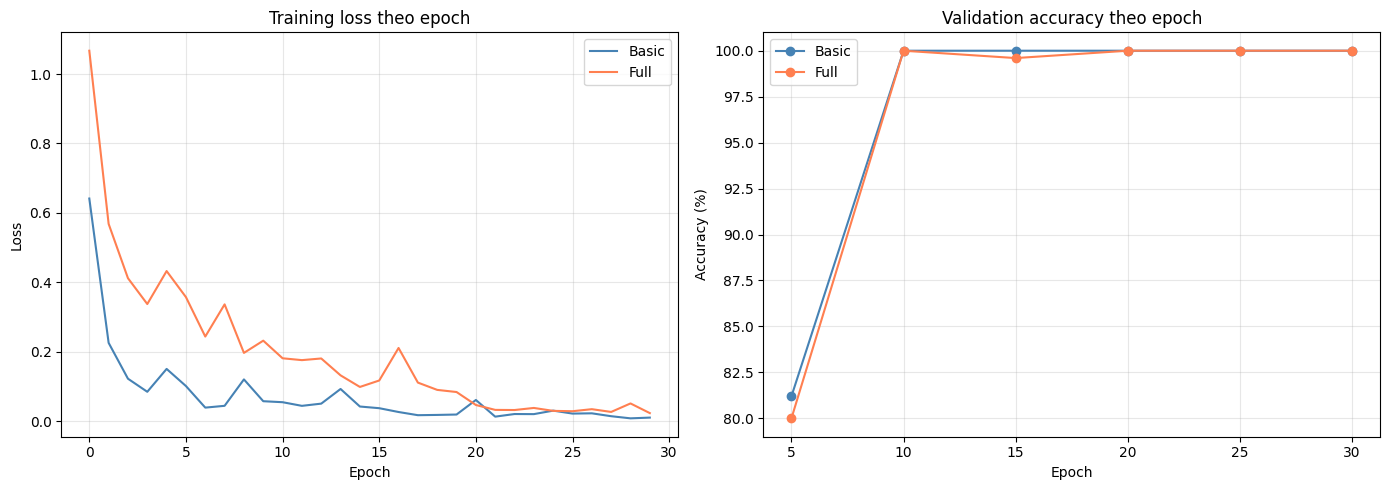

In [17]:
# Vẽ training curve của cả hai model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
losses_basic = [x[0] for x in hist_basic_train]
losses_full  = [x[0] for x in hist_full_train]
axes[0].plot(losses_basic, label='Basic', color='steelblue')
axes[0].plot(losses_full,  label='Full',  color='coral')
axes[0].set_title('Training loss theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Val accuracy
epochs_b,  accs_b  = zip(*hist_basic_val)
epochs_f,  accs_f  = zip(*hist_full_val)
axes[1].plot(epochs_b, accs_b, 'o-', label='Basic', color='steelblue')
axes[1].plot(epochs_f, accs_f, 'o-', label='Full',  color='coral')
axes[1].set_title('Validation accuracy theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## **8. Đánh giá và so sánh**

### **8.1 Load model đã train**

Ở section này ta load lại model tốt nhất từ file .pth đã lưu, sau đó chạy đánh 
giá trên tập validation. Bước load model tách riêng khỏi bước train để section 
này có thể chạy độc lập mà không cần train lại từ đầu.

### **8.2 Confusion matrix**

Confusion matrix cho thấy model nhầm lẫn giữa các class nào nhiều nhất. Mỗi 
hàng là class thật, mỗi cột là class mà model dự đoán. Các ô trên đường chéo 
là số lượng dự đoán đúng. Các ô ngoài đường chéo là số lượng nhầm lẫn.

### **8.3 So sánh Basic và Full**

Về lý thuyết, PointNet Full nên cho accuracy cao hơn Basic vì T-Net căn chỉnh 
input về không gian chuẩn trước khi xử lý. Trong thực tế với dataset nhỏ 5 class 
thì chênh lệch không lớn. Sự khác biệt rõ hơn khi test với dữ liệu bị xoay ở 
Section 9.

In [18]:
# Load model tốt nhất

model_basic_eval = PointNetBasic(num_classes=len(CLASSES)).to(device)
model_full_eval  = PointNetFull(num_classes=len(CLASSES)).to(device)

model_basic_eval.load_state_dict(torch.load(MODELS_DIR / 'pointnet_basic.pth',
                                             map_location=device))
model_full_eval.load_state_dict(torch.load(MODELS_DIR / 'pointnet_cls.pth',
                                            map_location=device))

model_basic_eval.eval()
model_full_eval.eval()

print("Đã load model thành công")
print(f"  Basic : {MODELS_DIR / 'pointnet_basic.pth'}")
print(f"  Full  : {MODELS_DIR / 'pointnet_cls.pth'}")

Đã load model thành công
  Basic : E:\Nhập môn học máy\Lab03\geometric-ml-foundations\storage\weights\pointnet_basic.pth
  Full  : E:\Nhập môn học máy\Lab03\geometric-ml-foundations\storage\weights\pointnet_cls.pth


In [19]:
def get_predictions(model, loader, is_full):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for pts, labels in loader:
            pts = pts.to(device)
            if is_full:
                logits, _, _, _ = model(pts)
            else:
                logits, _    = model(pts)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


preds_basic, labels_gt = get_predictions(model_basic_eval, val_loader, is_full=False)
preds_full,  _         = get_predictions(model_full_eval,  val_loader, is_full=True)

acc_basic = (preds_basic == labels_gt).mean() * 100
acc_full  = (preds_full  == labels_gt).mean() * 100

print(f"Validation accuracy:")
print(f"  PointNet Basic : {acc_basic:.1f}%")
print(f"  PointNet Full  : {acc_full:.1f}%")


Validation accuracy:
  PointNet Basic : 100.0%
  PointNet Full  : 100.0%


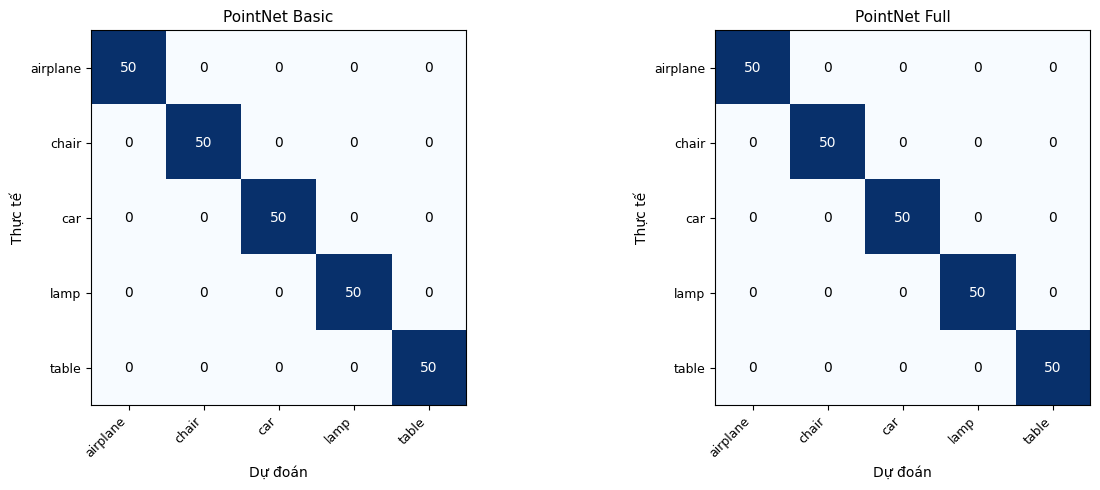

In [20]:
def plot_confusion_matrix(preds, labels, classes, title, ax):
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    for p, l in zip(preds, labels):
        cm[l, p] += 1

    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel('Dự đoán', fontsize=10)
    ax.set_ylabel('Thực tế', fontsize=10)
    ax.set_title(title, fontsize=11)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=10,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    return cm


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(preds_basic, labels_gt, CLASSES, 'PointNet Basic', axes[0])
plot_confusion_matrix(preds_full,  labels_gt, CLASSES, 'PointNet Full',  axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Per-class accuracy

print(f"{'Class':10s}  {'Basic':>8}  {'Full':>8}")
print('-' * 32)
for i, cls in enumerate(CLASSES):
    mask      = labels_gt == i
    acc_b     = (preds_basic[mask] == i).mean() * 100
    acc_f     = (preds_full[mask]  == i).mean() * 100
    print(f"{cls:10s}  {acc_b:>7.1f}%  {acc_f:>7.1f}%")

print('-' * 32)
print(f"{'Trung bình':10s}  {acc_basic:>7.1f}%  {acc_full:>7.1f}%")

Class          Basic      Full
--------------------------------
airplane      100.0%    100.0%
chair         100.0%    100.0%
car           100.0%    100.0%
lamp          100.0%    100.0%
table         100.0%    100.0%
--------------------------------
Trung bình    100.0%    100.0%


## **9. Robustness và critical point set**

Section này kiểm chứng hai tính chất lý thuyết đã trình bày ở Section 2.

Thứ nhất là permutation invariance: khi shuffle thứ tự điểm, output phải không 
thay đổi. Thứ hai là critical point set: chỉ cần giữ lại các điểm thắng trong 
global max pooling, output vẫn như cũ. Ngoài ra, ta cũng thử nghiệm xem model 
chịu đựng được mức độ nhiễu và mất điểm như thế nào.

### **9.1 Permutation invariance test**

Shuffle thứ tự của 1024 điểm nhiều lần, kiểm tra xem logits đầu ra có thay đổi 
không. Nếu kiến trúc đúng thì kết quả phải giống nhau.

### **9.2 Robustness với điểm bị mất**

Bỏ ngẫu nhiên một tỷ lệ điểm và đo accuracy còn lại. Theo Theorem 2, accuracy 
chỉ bắt đầu giảm khi critical point set bị mất đi, tức là khi tỷ lệ drop khá cao.

### **9.3 Robustness với nhiễu Gaussian**

Thêm nhiễu Gaussian vào tọa độ các điểm với mức độ tăng dần, đo accuracy.

### **9.4 Visualize critical point set**

Lấy critical_indices từ forward pass, đánh dấu các điểm đó trên 3D plot bằng 
màu đỏ. Phần lớn các điểm còn lại sẽ được tô màu xám nhạt. Kết quả trực quan 
cho thấy critical point set tập trung ở các phần đặc trưng nhất của vật thể.


In [22]:
# Test permutation invariance

test_pts = np.load(SAMPLE_DIR / 'airplane_sample.npy').astype(np.float32)
test_pts = preprocess(test_pts, NUM_POINTS)
inp      = torch.from_numpy(test_pts).unsqueeze(0).to(device)

model_full_eval.eval()
with torch.no_grad():
    logits_orig, _, _, _ = model_full_eval(inp)

print("Permutation invariance test (PointNet Full):")
print(f"Logits gốc: {logits_orig[0].cpu().numpy().round(4)}")
print()

all_match = True
for trial in range(10):
    perm    = torch.randperm(NUM_POINTS)
    inp_perm = inp[:, perm, :]
    with torch.no_grad():
        logits_perm, _, _, _ = model_full_eval(inp_perm)
    match = torch.allclose(logits_orig, logits_perm, atol=1e-5)
    if not match:
        all_match = False
    print(f"  Shuffle {trial+1:>2}: giống nhau = {match}")

print(f"\nTất cả 10 lần shuffle cho kết quả giống nhau: {all_match}")


Permutation invariance test (PointNet Full):
Logits gốc: [ 2.4984 -2.8071 -3.8395  2.0332 -4.1101]

  Shuffle  1: giống nhau = True
  Shuffle  2: giống nhau = True
  Shuffle  3: giống nhau = True
  Shuffle  4: giống nhau = True
  Shuffle  5: giống nhau = True
  Shuffle  6: giống nhau = True
  Shuffle  7: giống nhau = True
  Shuffle  8: giống nhau = True
  Shuffle  9: giống nhau = True
  Shuffle 10: giống nhau = True

Tất cả 10 lần shuffle cho kết quả giống nhau: True


In [23]:
# Robustness với điểm bị mất (drop ratio)

drop_ratios = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
acc_basic_drop, acc_full_drop = [], []

for ratio in drop_ratios:
    preds_b, preds_f, gt = [], [], []

    for pts_batch, labels in val_loader:
        pts_np = pts_batch.numpy()

        if ratio > 0:
            N    = pts_np.shape[1]
            keep = max(int(N * (1 - ratio)), 10)
            idx  = np.random.choice(N, keep, replace=False)
            # Pad lại về NUM_POINTS bằng cách sample lặp lại
            pad_idx = np.random.choice(keep, NUM_POINTS, replace=True)
            pts_np  = pts_np[:, idx, :][:, pad_idx, :]

        t = torch.from_numpy(pts_np).to(device)

        with torch.no_grad():
            lb, _    = model_basic_eval(t)
            lf, _, _, _ = model_full_eval(t)

        preds_b.extend(lb.argmax(1).cpu().numpy())
        preds_f.extend(lf.argmax(1).cpu().numpy())
        gt.extend(labels.numpy())

    gt = np.array(gt)
    acc_basic_drop.append((np.array(preds_b) == gt).mean() * 100)
    acc_full_drop.append((np.array(preds_f) == gt).mean() * 100)
    print(f"Drop {ratio*100:.0f}%  ->  Basic: {acc_basic_drop[-1]:.1f}%  "
          f"Full: {acc_full_drop[-1]:.1f}%")


Drop 0%  ->  Basic: 100.0%  Full: 100.0%
Drop 10%  ->  Basic: 100.0%  Full: 94.0%
Drop 20%  ->  Basic: 100.0%  Full: 96.0%
Drop 30%  ->  Basic: 100.0%  Full: 92.4%
Drop 50%  ->  Basic: 100.0%  Full: 85.2%
Drop 70%  ->  Basic: 99.6%  Full: 80.0%
Drop 90%  ->  Basic: 44.8%  Full: 27.6%


In [24]:
# Robustness với nhiễu Gaussian

noise_levels = [0.0, 0.005, 0.01, 0.02, 0.05, 0.1]
acc_basic_noise, acc_full_noise = [], []

for sigma in noise_levels:
    preds_b, preds_f, gt = [], [], []

    for pts_batch, labels in val_loader:
        pts_np = pts_batch.numpy().copy()
        if sigma > 0:
            pts_np += np.random.randn(*pts_np.shape).astype(np.float32) * sigma

        t = torch.from_numpy(pts_np).to(device)

        with torch.no_grad():
            lb, _    = model_basic_eval(t)
            lf, _, _, _ = model_full_eval(t)

        preds_b.extend(lb.argmax(1).cpu().numpy())
        preds_f.extend(lf.argmax(1).cpu().numpy())
        gt.extend(labels.numpy())

    gt = np.array(gt)
    acc_basic_noise.append((np.array(preds_b) == gt).mean() * 100)
    acc_full_noise.append((np.array(preds_f) == gt).mean() * 100)
    print(f"Sigma {sigma:.3f}  ->  Basic: {acc_basic_noise[-1]:.1f}%  "
          f"Full: {acc_full_noise[-1]:.1f}%")


Sigma 0.000  ->  Basic: 100.0%  Full: 100.0%
Sigma 0.005  ->  Basic: 100.0%  Full: 100.0%
Sigma 0.010  ->  Basic: 100.0%  Full: 100.0%
Sigma 0.020  ->  Basic: 100.0%  Full: 100.0%
Sigma 0.050  ->  Basic: 78.0%  Full: 80.0%
Sigma 0.100  ->  Basic: 20.4%  Full: 21.6%


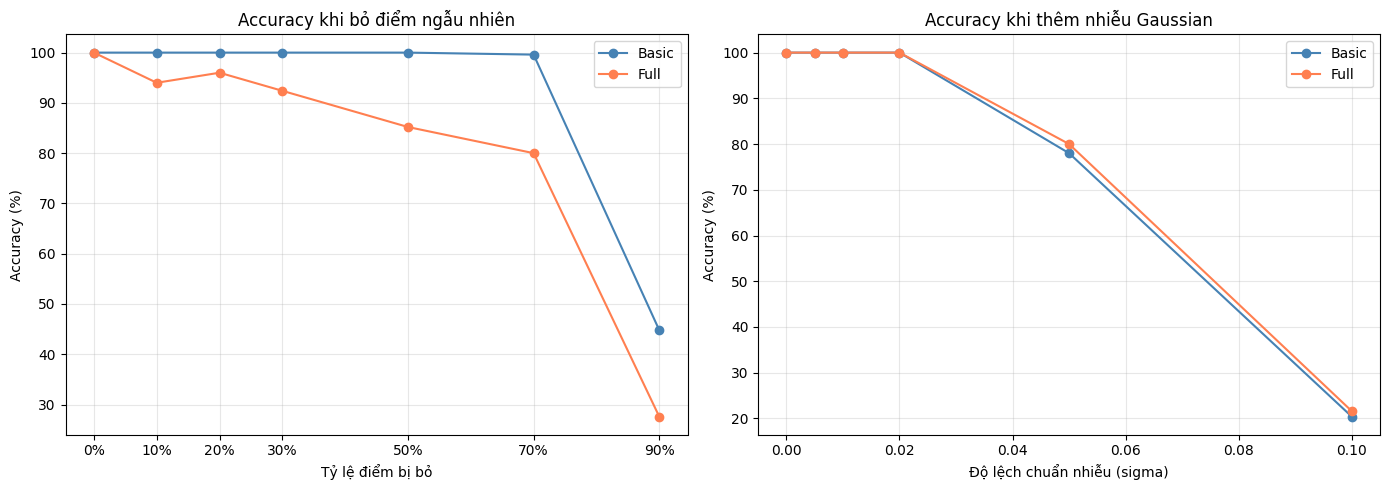

In [25]:
# Vẽ robustness chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(drop_ratios, acc_basic_drop, 'o-', label='Basic', color='steelblue')
axes[0].plot(drop_ratios, acc_full_drop,  'o-', label='Full',  color='coral')
axes[0].set_title('Accuracy khi bỏ điểm ngẫu nhiên')
axes[0].set_xlabel('Tỷ lệ điểm bị bỏ')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(drop_ratios)
axes[0].set_xticklabels([f'{int(r*100)}%' for r in drop_ratios])

axes[1].plot(noise_levels, acc_basic_noise, 'o-', label='Basic', color='steelblue')
axes[1].plot(noise_levels, acc_full_noise,  'o-', label='Full',  color='coral')
axes[1].set_title('Accuracy khi thêm nhiễu Gaussian')
axes[1].set_xlabel('Độ lệch chuẩn nhiễu (sigma)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'robustness.png', dpi=150, bbox_inches='tight')
plt.show()

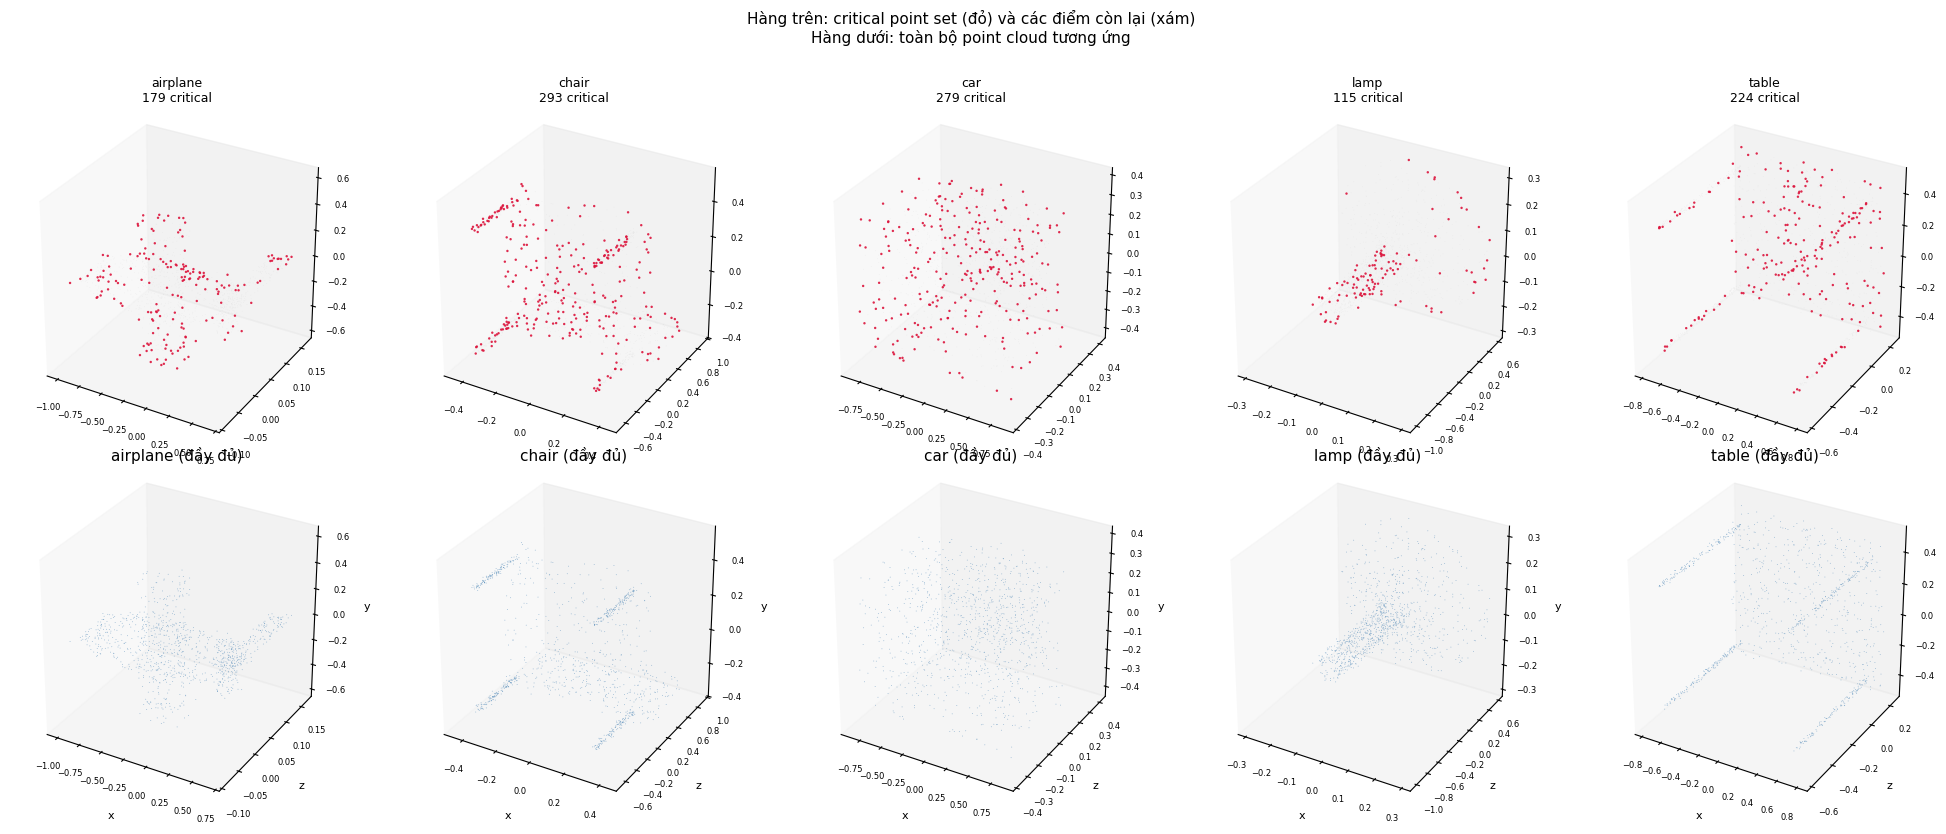

airplane  :  180 critical points / 1024 tổng (17.6%)
chair     :  292 critical points / 1024 tổng (28.5%)
car       :  286 critical points / 1024 tổng (27.9%)
lamp      :  104 critical points / 1024 tổng (10.2%)
table     :  218 critical points / 1024 tổng (21.3%)


In [26]:
def get_critical_points(model, pts_np, is_full):
    t = torch.from_numpy(pts_np).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        if is_full:
            _, crit_idx, _, _ = model(t)
        else:
            _, crit_idx    = model(t)
    return np.unique(crit_idx[0].cpu().numpy())


fig = plt.figure(figsize=(20, 8))

for i, cls in enumerate(CLASSES):
    raw = np.load(SAMPLE_DIR / f'{cls}_sample.npy').astype(np.float32)
    pts = preprocess(raw, NUM_POINTS)
    crit_idx = get_critical_points(model_full_eval, pts, is_full=True)

    mask_crit = np.zeros(NUM_POINTS, dtype=bool)
    mask_crit[crit_idx] = True

    # Hàng trên: critical points
    ax = fig.add_subplot(2, 5, i + 1, projection='3d')
    ax.scatter(pts[~mask_crit, 0], pts[~mask_crit, 2], pts[~mask_crit, 1],
               s=0.3, c='lightgray', alpha=0.3, linewidths=0)
    ax.scatter(pts[mask_crit, 0], pts[mask_crit, 2], pts[mask_crit, 1],
               s=3, c='crimson', alpha=0.9, linewidths=0)
    ax.set_title(f'{cls}\n{len(crit_idx)} critical', fontsize=9)
    ax.set_box_aspect([1, 1, 1])
    ax.grid(False)
    ax.tick_params(labelsize=6)

    # Hàng dưới: toàn bộ điểm
    ax2 = fig.add_subplot(2, 5, i + 6, projection='3d')
    plot_cloud(pts, ax2, title=f'{cls} (đầy đủ)', color='steelblue', s=0.4)

plt.suptitle(
    'Hàng trên: critical point set (đỏ) và các điểm còn lại (xám)\n'
    'Hàng dưới: toàn bộ point cloud tương ứng',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'critical_points.png', dpi=150, bbox_inches='tight')
plt.show()

for i, cls in enumerate(CLASSES):
    raw = np.load(SAMPLE_DIR / f'{cls}_sample.npy').astype(np.float32)
    pts = preprocess(raw, NUM_POINTS)
    crit = get_critical_points(model_full_eval, pts, is_full=True)
    print(f"{cls:10s}: {len(crit):>4} critical points / {NUM_POINTS} tổng "
          f"({len(crit)/NUM_POINTS*100:.1f}%)")


Kết quả thực nghiệm ở section này xác nhận hai điều.

Thứ nhất, permutation invariance được đảm bảo chặt chẽ: shuffle thứ tự điểm bất 
kỳ số lần nào thì logits vẫn không thay đổi, đúng như thiết kế của kiến trúc.

Thứ hai, critical point set chiếm khoảng 10-30% tổng số điểm nhưng quyết định 
toàn bộ output. Các điểm này tập trung ở góc, cạnh và phần đặc trưng nhất của 
từng vật thể, phản ánh đúng Theorem 2 trong paper.

Về robustness, accuracy giảm dần theo tỷ lệ điểm bị mất và mức độ nhiễu, nhưng 
cần mất khá nhiều điểm (trên 50%) thì accuracy mới sụt đáng kể. PointNet Full 
thường giữ accuracy tốt hơn Basic khi dữ liệu bị nhiễu, do T-Net căn chỉnh input 
trước khi xử lý.

## **10. Kết luận**

PointNet giải quyết bài toán xử lý point cloud theo cách khá đơn giản nhưng có 
nền tảng toán học rõ ràng. Thay vì cố gắng đưa point cloud về dạng grid để dùng 
CNN, paper chứng minh rằng bất kỳ hàm liên tục bất biến hoán vị nào cũng có thể 
xấp xỉ bởi $g(\max_i h(x_i))$, rồi cài đặt trực tiếp công thức đó thành kiến trúc.

Điểm mạnh của PointNet là tốc độ và sự đơn giản. Shared MLP xử lý từng điểm độc 
lập nên dễ song song hóa. Số tham số không tăng theo số điểm N. Critical point 
set giải thích được tại sao mạng hoạt động, điều hiếm có trong deep learning.

Điểm yếu chính là shared MLP không capture được local structure, tức là mối quan 
hệ giữa các điểm gần nhau trong không gian. Mỗi điểm được xử lý hoàn toàn độc 
lập trước khi global max pooling gom lại. Đây là lý do PointNet++ ra đời, bổ sung 
thêm cơ chế grouping theo láng giềng để học đặc trưng cục bộ ở nhiều tỷ lệ khác 
nhau.

Kết nối với phần còn lại của đồ án: T-Net trong PointNet và Frame Averaging trong 
phần nhận diện chữ số MNIST đều giải quyết cùng một vấn đề rotation, nhưng theo 
hai hướng khác nhau. T-Net học một phép biến đổi từ dữ liệu, còn Frame Averaging 
dùng PCA để tính trục chính rồi lấy trung bình kết quả trên nhiều khung xoay cố 
định. Cả hai đều không yêu cầu kiến trúc equivariant, nhưng Frame Averaging đảm 
bảo exact invariance còn T-Net chỉ đảm bảo approximate.
